In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
files = {
    "Amman": "Amman.csv",
    "Irbid": "Irbid.csv",
    "Zarqa": "Zarqa.csv"
}

pollutants = ["PM10", "NO2", "SO2"]

OUTPUT_DIR = "./outputs_corr"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
dfs = []
for city, f in files.items():
    df = pd.read_csv(f)
    df["Date"] = pd.to_datetime(df["Date"])
    df["City"] = city
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# ----------------------------
# 3. COMPUTE CITY-SPECIFIC CORRELATION MATRICES
# ----------------------------

corr_dict = {}

for city in files.keys():
    sub = data[data["City"] == city][pollutants]
    corr_matrix = sub.corr(method="pearson")
    corr_dict[city] = corr_matrix

In [6]:
combined_cols = []
combined_data = []

for city, mat in corr_dict.items():
    # mat is a 3x3 DataFrame with index and columns = pollutants
    # We'll stack them side by side
    combined_cols.extend([(city, col) for col in mat.columns])
    combined_data.append(mat.values)

# combined_data is a list of arrays shape (3,3); we concatenate horizontally
combined_array = np.concatenate(combined_data, axis=1)

combined_index = pollutants  # same for all
combined_columns = pd.MultiIndex.from_tuples(combined_cols, names=["City", "Pollutant"])

combined_corr_df = pd.DataFrame(combined_array, index=combined_index, columns=combined_columns)

# Save combined table
combined_corr_df.to_csv(os.path.join(OUTPUT_DIR, "correlation_matrix_all_cities.csv"))

print("Combined correlation matrix:")
combined_corr_df

Combined correlation matrix:


City          Amman                         Irbid                      \
Pollutant      PM10       NO2       SO2      PM10       NO2       SO2   
PM10       1.000000  0.188683  0.446374  1.000000  0.356444  0.240905   
NO2        0.188683  1.000000  0.525755  0.356444  1.000000  0.206537   
SO2        0.446374  0.525755  1.000000  0.240905  0.206537  1.000000   

City          Zarqa                      
Pollutant      PM10       NO2       SO2  
PM10       1.000000  0.076266  0.019800  
NO2        0.076266  1.000000  0.716081  
SO2        0.019800  0.716081  1.000000

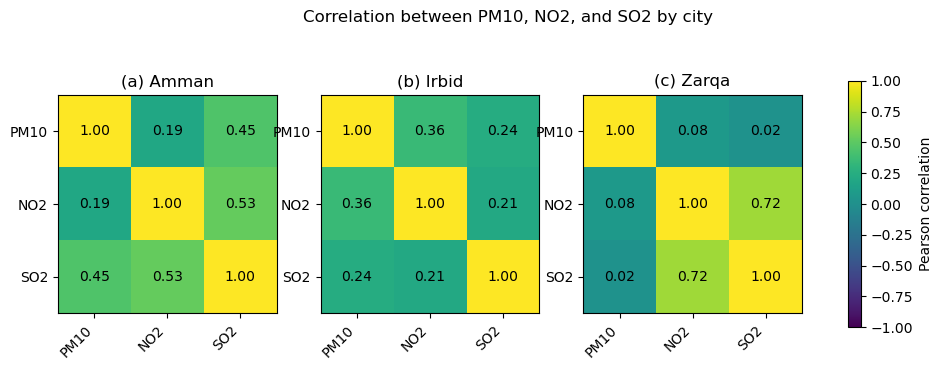


Saved combined correlation table and figure in: ./outputs_corr


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
panel_labels = ["(a)", "(b)", "(c)"]

for i, city in enumerate(files.keys()):
    ax = axes[i]
    mat = corr_dict[city]  # 3x3 DataFrame

    im = ax.imshow(mat.values, vmin=-1, vmax=1)  # correlation range -1 to 1

    # Set ticks and tick labels
    ax.set_xticks(range(len(pollutants)))
    ax.set_yticks(range(len(pollutants)))
    ax.set_xticklabels(pollutants, rotation=45, ha="right")
    ax.set_yticklabels(pollutants)

    # Title and panel label
    ax.set_title(panel_labels[i]+' '+city)
    #ax.text(0.02, 0.95, panel_labels[i],
    #        transform=ax.transAxes,
    #        va="top", ha="left", fontweight="bold")

    # Annotate with correlation values
    for r in range(len(pollutants)):
        for c in range(len(pollutants)):
            ax.text(c, r, f"{mat.values[r, c]:.2f}",
                    ha="center", va="center", fontsize=10)

# Add a single colorbar for all subplots
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
cbar.set_label("Pearson correlation")

fig.suptitle("Correlation between PM10, NO2, and SO2 by city", size=12)
#fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "Figure_corr_heatmaps_all_cities.png"), dpi=300)
plt.show()
plt.close(fig)

print(f"\nSaved combined correlation table and figure in: {OUTPUT_DIR}")